Lowest eigenvalues:
  n =  0, E = 0.194678317646
  n =  1, E = 0.196228199503
  n =  2, E = 0.559499809675
  n =  3, E = 0.563056643839
  n =  4, E = 0.863202949445
  n =  5, E = 0.884415878580

Displayed state index: 0
Probability in left well:  0.99999532
Probability in right well: 0.00000468
Grid spacing dx: 1.307190e-03
hbar: 0.1

Computing Husimi distribution...


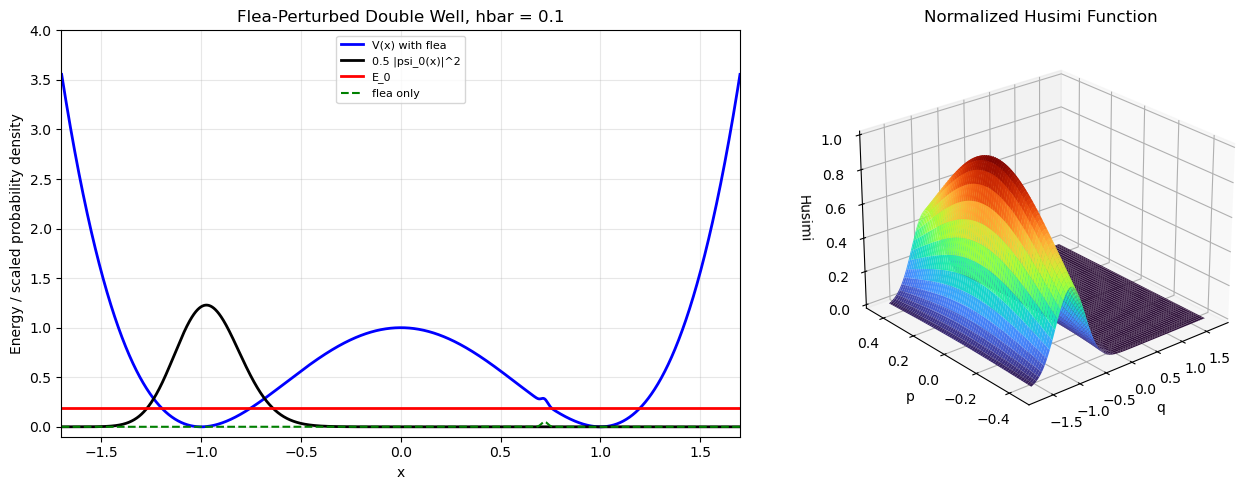

In [1]:
# ============================================================
# Flea on Schrödinger's Cat:
# Double-well eigenfunction simulation with a flea perturbation
#
# This code computes low-lying eigenvalues/eigenfunctions for
# a 1D double-well potential with a small smooth bump ("flea").
#
# It reproduces the qualitative behavior shown in Fig. 5 of:
# Landsman & Reuvers, "A Flea on Schrödinger's Cat".
#
# Requirements:
#   numpy
#   scipy
#   matplotlib
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import diags
from scipy.sparse.linalg import eigsh

# For optional 3D Husimi plot
from mpl_toolkits.mplot3d import Axes3D


# ============================================================
# 1. USER SETTINGS
# ============================================================

# Physical / numerical parameters
HBAR = 0.1
MASS = 0.5       # MASS = 0.5 gives kinetic term -hbar^2 d^2/dx^2

# Spatial domain
X_MIN = -1.7
X_MAX =  1.7

# Number of interior grid points.
# Increase this for sharper small-hbar plots.
GRID_POINTS = 2600

# Number of eigenstates to compute
N_EIGS = 6

# Which eigenstate to display?
# 0 = ground state, 1 = first excited state, etc.
STATE_INDEX = 0

# Double-well parameters
# Potential is V(x) = (lambda_/4) * (x^2 - a^2)^2.
# For a = 1 and lambda = 4, this is V(x) = (x^2 - 1)^2,
# giving barrier height 1 at x = 0.
WELL_A = 1.0
LAMBDA = 4.0

# Flea perturbation parameters
# Positive flea in the right well localizes the ground state to the left.
USE_FLEA = True
FLEA_CENTER = 0.72
FLEA_HALF_WIDTH = 0.15
FLEA_HEIGHT = 0.05

# Plot settings
DENSITY_SCALE = 0.50     # scale |psi|^2 to fit same axis as V(x)
Y_MIN = -0.1
Y_MAX = 4.0

# Optional Husimi plot.
# Set to False if the code runs too slowly on your machine.
MAKE_HUSIMI = True

# Husimi grid settings
HUSIMI_Q_POINTS = 140
HUSIMI_P_POINTS = 140
P_MIN = -0.45
P_MAX =  0.45

# Save figure?
SAVE_FIGURE = False
FIGURE_NAME = "flea_double_well.png"


# ============================================================
# 2. POTENTIAL FUNCTIONS
# ============================================================

def double_well_potential(x, a=WELL_A, lambda_=LAMBDA):
    """
    Symmetric double well:
        V(x) = (lambda / 4) * (x^2 - a^2)^2

    For a = 1 and lambda = 4:
        V(x) = (x^2 - 1)^2
    """
    return (lambda_ / 4.0) * (x**2 - a**2)**2


def smooth_flea_bump(x, center=FLEA_CENTER, half_width=FLEA_HALF_WIDTH, height=FLEA_HEIGHT):
    """
    Smooth compactly supported bump function.

    The bump is nonzero only for |x - center| < half_width.
    It reaches height approximately equal to 'height' at x = center.

    Formula:
        height * exp(1/c^2 - 1/(c^2 - (x-b)^2))
    """
    b = center
    c = half_width
    d = height

    bump = np.zeros_like(x)
    mask = np.abs(x - b) < c

    bump[mask] = d * np.exp(
        1.0 / c**2 - 1.0 / (c**2 - (x[mask] - b)**2)
    )

    return bump


def total_potential(x):
    """
    Total potential = double well + optional flea.
    """
    V = double_well_potential(x)

    if USE_FLEA:
        V = V + smooth_flea_bump(x)

    return V


# ============================================================
# 3. GRID AND HAMILTONIAN
# ============================================================

def make_grid(x_min=X_MIN, x_max=X_MAX, n=GRID_POINTS):
    """
    Make an interior grid for Dirichlet boundary conditions.

    The endpoints x_min and x_max are treated as boundaries where psi = 0.
    The Hamiltonian is built only on interior points.
    """
    full_grid = np.linspace(x_min, x_max, n + 2)
    x = full_grid[1:-1]
    dx = full_grid[1] - full_grid[0]
    return x, dx


def build_hamiltonian(x, dx, hbar=HBAR, mass=MASS):
    """
    Build sparse finite-difference Hamiltonian:

        H = -(hbar^2 / 2m) D2 + V(x)

    with central second derivative:

        psi''(x_i) ≈ (psi_{i+1} - 2 psi_i + psi_{i-1}) / dx^2
    """
    n = len(x)

    main_diag = -2.0 * np.ones(n)
    off_diag = np.ones(n - 1)

    D2 = diags(
        diagonals=[off_diag, main_diag, off_diag],
        offsets=[-1, 0, 1],
        shape=(n, n),
        format="csc"
    ) / dx**2

    V = total_potential(x)
    V_matrix = diags(V, 0, format="csc")

    H = -(hbar**2 / (2.0 * mass)) * D2 + V_matrix

    return H, V


# ============================================================
# 4. EIGENVALUE SOLVER
# ============================================================

def normalize_wavefunctions(x, psi_matrix):
    """
    Normalize eigenvectors so that integral |psi|^2 dx = 1.
    """
    dx = x[1] - x[0]

    psi_normed = psi_matrix.copy()

    for j in range(psi_normed.shape[1]):
        norm = np.sqrt(np.sum(np.abs(psi_normed[:, j])**2) * dx)
        psi_normed[:, j] = psi_normed[:, j] / norm

        # Fix arbitrary sign so the largest peak is positive
        max_index = np.argmax(np.abs(psi_normed[:, j]))
        if np.real(psi_normed[max_index, j]) < 0:
            psi_normed[:, j] *= -1

    return psi_normed


def solve_eigenproblem():
    """
    Compute the lowest N_EIGS eigenvalues/eigenfunctions.
    """
    x, dx = make_grid()
    H, V = build_hamiltonian(x, dx)

    # Sparse Hermitian eigenvalue solver.
    # 'SA' means smallest algebraic eigenvalues.
    E, psi = eigsh(H, k=N_EIGS, which="SA", tol=1e-11, maxiter=200000)

    # Sort eigenvalues and corresponding eigenvectors
    idx = np.argsort(E)
    E = E[idx]
    psi = psi[:, idx]

    psi = normalize_wavefunctions(x, psi)

    return x, dx, V, E, psi


# ============================================================
# 5. DIAGNOSTICS
# ============================================================

def left_right_probabilities(x, psi):
    """
    Compute probability in left and right wells.
    """
    dx = x[1] - x[0]

    left_mask = x < 0
    right_mask = x > 0

    p_left = np.sum(np.abs(psi[left_mask])**2) * dx
    p_right = np.sum(np.abs(psi[right_mask])**2) * dx

    return p_left, p_right


# ============================================================
# 6. HUSIMI DISTRIBUTION
# ============================================================

def husimi_distribution(x, psi, hbar=HBAR,
                        q_points=HUSIMI_Q_POINTS,
                        p_points=HUSIMI_P_POINTS,
                        p_min=P_MIN,
                        p_max=P_MAX):
    """
    Compute a simple Husimi distribution:

        H(p,q) = |<Phi_{p,q} | psi>|^2

    where Phi_{p,q} is a coherent state.

    This is mainly for visualization, not for high-performance computation.
    """
    dx = x[1] - x[0]

    q_grid = np.linspace(x.min(), x.max(), q_points)
    p_grid = np.linspace(p_min, p_max, p_points)

    # Precompute p-dependent phase factor:
    # conjugate of exp(i p x / hbar) is exp(-i p x / hbar)
    phase_px = np.exp(-1j * p_grid[:, None] * x[None, :] / hbar)

    H = np.zeros((p_points, q_points))

    coherent_norm = (np.pi * hbar)**(-0.25)

    for j, q in enumerate(q_grid):
        gaussian_q = np.exp(-(x - q)**2 / (2.0 * hbar))

        # Coherent-state overlap as function of p
        # conjugate coherent state contributes exp(+ i p q / 2hbar)
        phase_pq = np.exp(1j * p_grid * q / (2.0 * hbar))

        weighted_psi = gaussian_q * psi

        amplitudes = (
            coherent_norm
            * phase_pq
            * (phase_px @ weighted_psi)
            * dx
        )

        H[:, j] = np.abs(amplitudes)**2

    # Normalize for plotting so max height is 1
    if H.max() > 0:
        H = H / H.max()

    return q_grid, p_grid, H


# ============================================================
# 7. RUN SIMULATION
# ============================================================

x, dx, V, E, psi_matrix = solve_eigenproblem()

psi = psi_matrix[:, STATE_INDEX]
density = np.abs(psi)**2

p_left, p_right = left_right_probabilities(x, psi)

print("Lowest eigenvalues:")
for n in range(min(N_EIGS, len(E))):
    print(f"  n = {n:2d}, E = {E[n]:.12f}")

print()
print(f"Displayed state index: {STATE_INDEX}")
print(f"Probability in left well:  {p_left:.8f}")
print(f"Probability in right well: {p_right:.8f}")
print(f"Grid spacing dx: {dx:.6e}")
print(f"hbar: {HBAR}")


# ============================================================
# 8. PLOT RESULTS
# ============================================================

if MAKE_HUSIMI:
    fig = plt.figure(figsize=(14, 5))

    # Left panel: potential, scaled density, energy
    ax1 = fig.add_subplot(1, 2, 1)

else:
    fig, ax1 = plt.subplots(figsize=(7, 5))


# Plot total potential
ax1.plot(x, V, color="blue", lw=2, label="V(x) with flea")

# Plot scaled probability density
ax1.plot(
    x,
    DENSITY_SCALE * density,
    color="black",
    lw=2,
    label=f"{DENSITY_SCALE:g} |psi_{STATE_INDEX}(x)|^2"
)

# Plot energy line
ax1.axhline(E[STATE_INDEX], color="red", lw=2, label=f"E_{STATE_INDEX}")

# Also plot flea alone, if desired, as a dashed small curve
if USE_FLEA:
    flea = smooth_flea_bump(x)
    ax1.plot(x, flea, color="green", ls="--", lw=1.5, label="flea only")

ax1.set_xlabel("x")
ax1.set_ylabel("Energy / scaled probability density")
ax1.set_title(
    f"Flea-Perturbed Double Well, hbar = {HBAR}"
)
ax1.set_xlim(X_MIN, X_MAX)
ax1.set_ylim(Y_MIN, Y_MAX)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper center", fontsize=8)


# Right panel: Husimi function
if MAKE_HUSIMI:
    print("\nComputing Husimi distribution...")

    q_grid, p_grid, H_husimi = husimi_distribution(x, psi)

    Q, P = np.meshgrid(q_grid, p_grid)

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    ax2.plot_surface(
        Q,
        P,
        H_husimi,
        cmap="turbo",
        linewidth=0,
        antialiased=True,
        rstride=2,
        cstride=2
    )

    ax2.set_xlabel("q")
    ax2.set_ylabel("p")
    ax2.set_zlabel("Husimi")
    ax2.set_title("Normalized Husimi Function")
    ax2.view_init(elev=25, azim=-130)

plt.tight_layout()

if SAVE_FIGURE:
    plt.savefig(FIGURE_NAME, dpi=200)
    print(f"\nSaved figure as: {FIGURE_NAME}")

plt.show()

Running open-system double-well simulations

hbar = 0.2
------------------------------------------------------------
Unperturbed low eigenvalues:
  H0 state 0: E = 0.3740248325
  H0 state 1: E = 0.3800716345
  H0 state 2: E = 0.9422802311
  H0 state 3: E = 1.0861519375
  H0 state 4: E = 1.4714182845
  H0 state 5: E = 1.8592535676
Flea Hamiltonian low eigenvalues:
  HF state 0: E = 0.3752909048
  HF state 1: E = 0.3822356820
  HF state 2: E = 0.9427576266
  HF state 3: E = 1.0875026280
  HF state 4: E = 1.4730056967
  HF state 5: E = 1.8597761594

Initial-state projection norm in final basis = 1.00000000
Final flea ground-state P_left  = 0.74632965
Final flea ground-state P_right = 0.25367035
Target localization side = left

First crossing P_target >= 0.9: None
Persistent P_target >= 0.9:   None
First crossing fidelity >= 0.95:   3.381535038932147
Persistent fidelity >= 0.95:       3.381535038932147

hbar = 0.1
------------------------------------------------------------
Unperturbed low

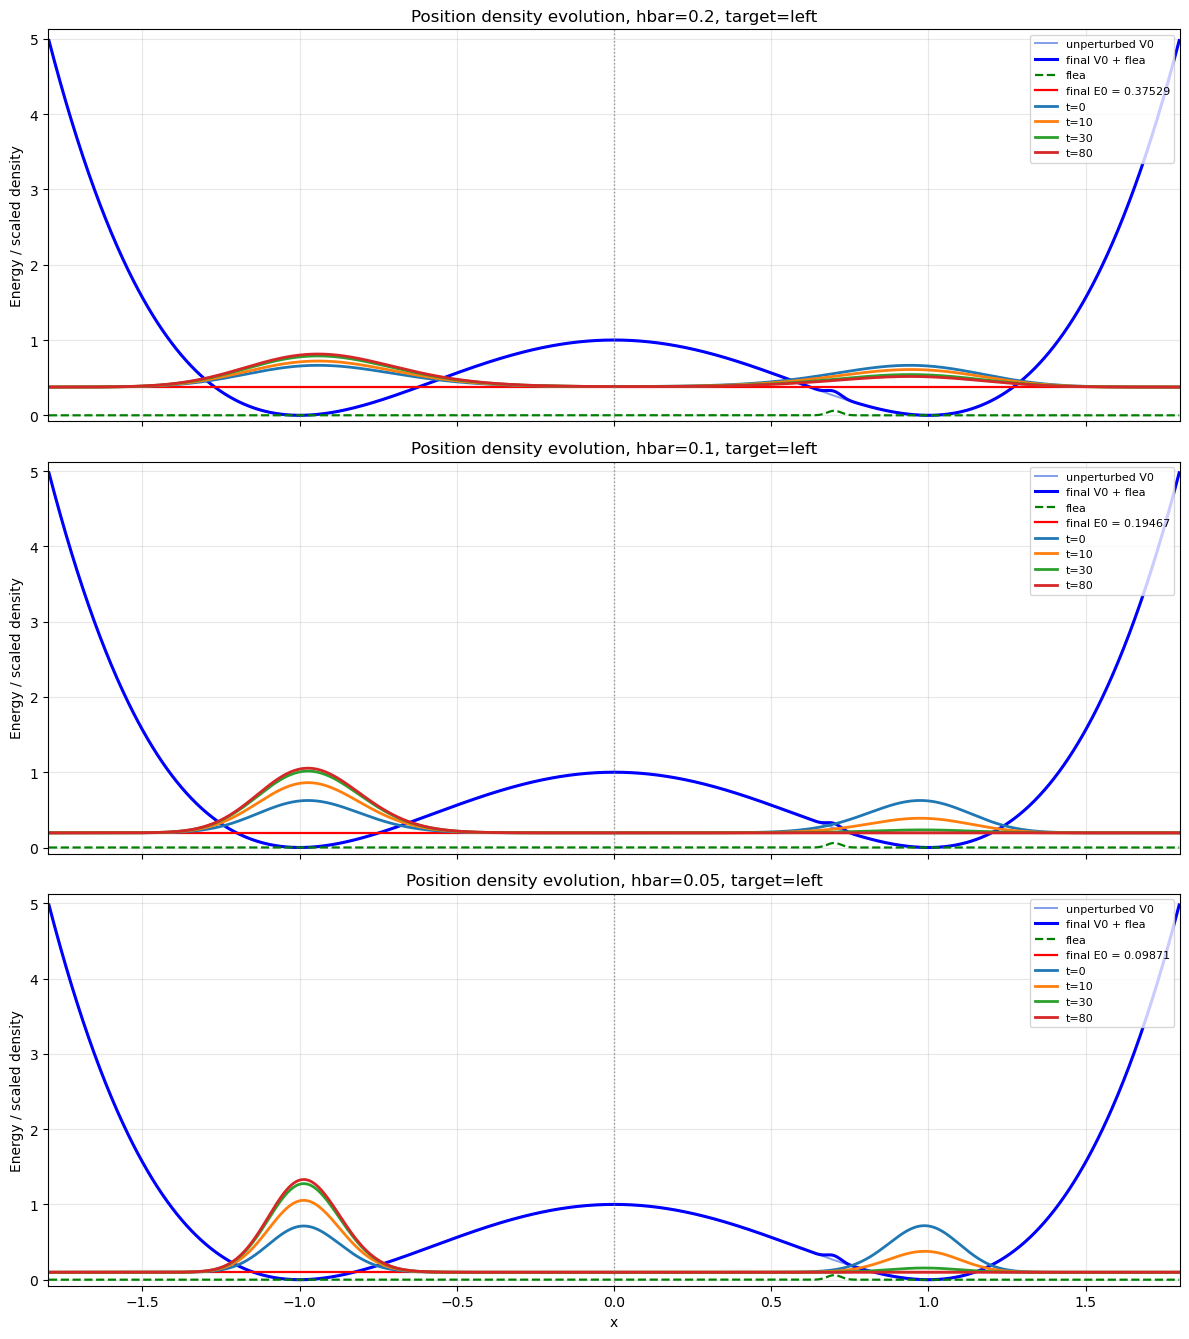

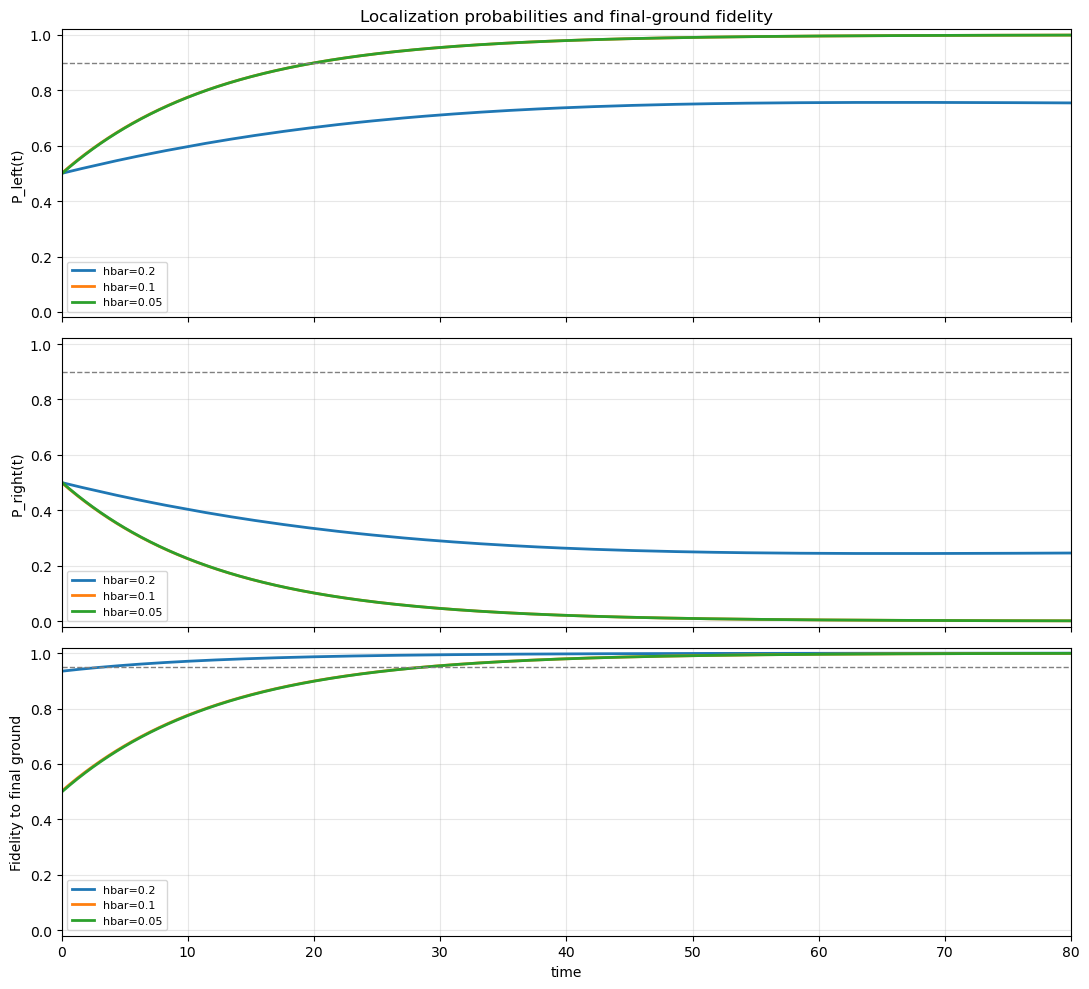

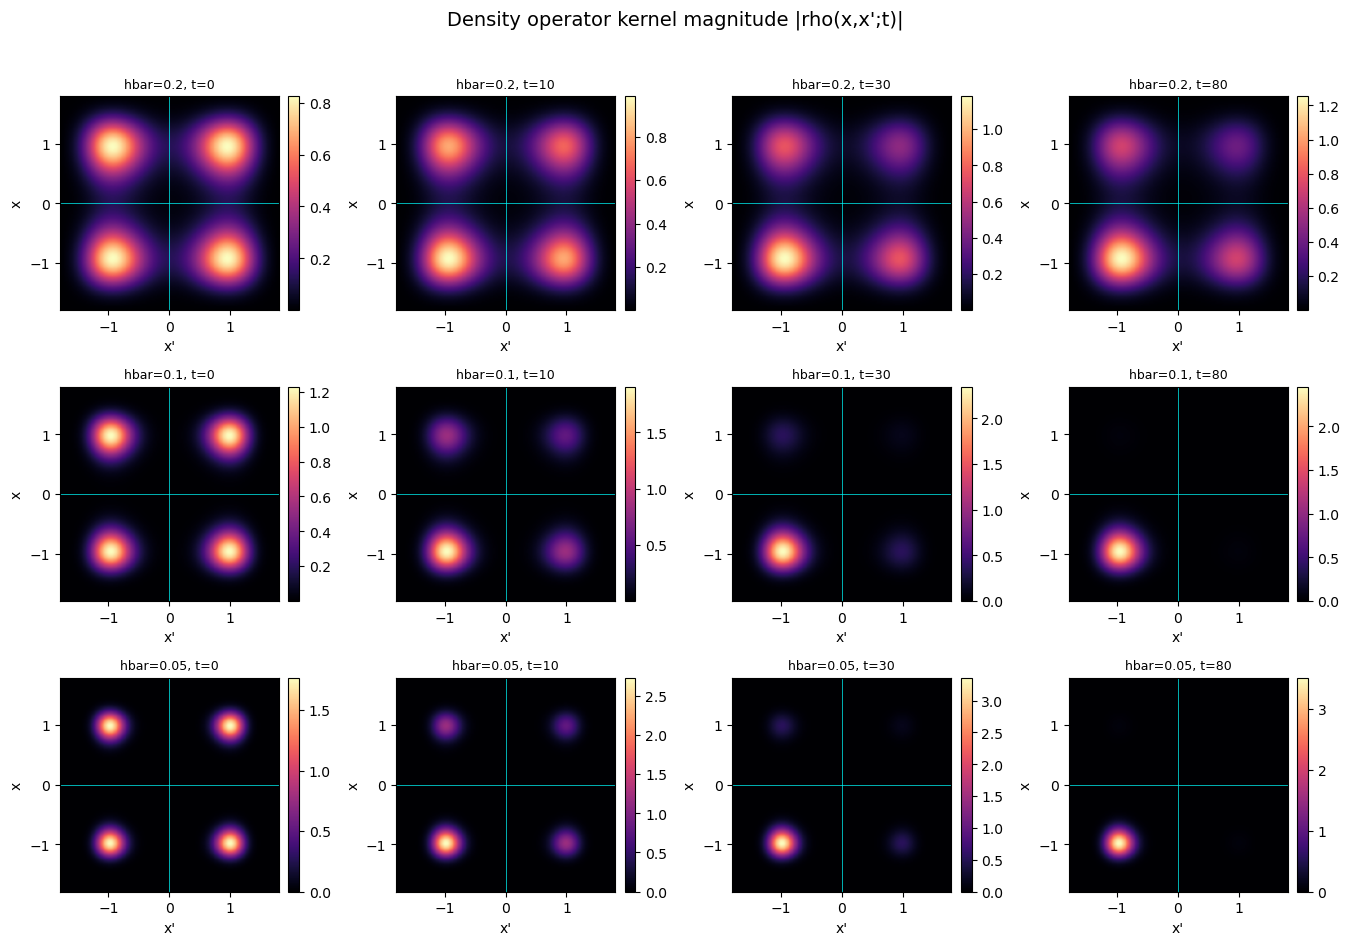


Summary

hbar = 0.2
target side = left
final P_left  = 0.746330
final P_right = 0.253670
projection norm = 1.000000
t_loc_first      = None
t_loc_persistent = None
t_fid_first      = 3.381535038932147
t_fid_persistent = 3.381535038932147

hbar = 0.1
target side = left
final P_left  = 0.999997
final P_right = 0.000003
projection norm = 1.000000
t_loc_first      = 20.200222469410456
t_loc_persistent = 20.200222469410456
t_fid_first      = 28.832035595105673
t_fid_persistent = 28.832035595105673

hbar = 0.05
target side = left
final P_left  = 1.000000
final P_right = 0.000000
projection norm = 1.000000
t_loc_first      = 20.200222469410456
t_loc_persistent = 20.200222469410456
t_fid_first      = 28.832035595105673
t_fid_persistent = 28.832035595105673


In [2]:
# ============================================================
# Open-system double-well simulation:
# instantaneous flea + relaxation Lindblad dynamics
#
# Master equation:
#
#   d rho / dt = -i/hbar [H_F, rho]
#                + sum_n gamma_n (L_n rho L_n^dagger
#                - 1/2 {L_n^dagger L_n, rho})
#
# with:
#
#   L_n = |phi_0^F><phi_n^F|, n > 0
#
# The initial state is the ground state of the unperturbed
# double well. The flea is turned on instantaneously at t = 0.
#
# We solve dynamics analytically in the eigenbasis of H_F.
# ============================================================


import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigvalsh


# ============================================================
# 1. USER SETTINGS
# ============================================================

# Three hbar values
HBAR_VALUES = [0.20, 0.1, 0.05]

# Mass.
# MASS = 0.5 gives kinetic term -hbar^2 d^2/dx^2.
MASS = 0.5

# Double-well potential:
# V0(x) = (lambda / 4) * (x^2 - a^2)^2
WELL_A = 1.0
LAMBDA = 4.0

# Spatial domain
X_MIN = -1.8
X_MAX =  1.8

# Grid points.
# Increase if you decrease hbar further.
GRID_POINTS = 1400

# Number of eigenstates used for the truncated open-system basis.
# Increase if the printed "initial-state projection norm" is too small.
N_BASIS = 36

# Number of low eigenvalues to print
N_PRINT_EIGS = 6

# Flea parameters: positive bump in right well.
# A positive flea on the right raises the right well and should localize
# the final ground state in the left well for small hbar.
FLEA_CENTER = 0.70
FLEA_HALF_WIDTH = 0.18
FLEA_HEIGHT = 0.060

# Relaxation rate.
# This is the dissipative strength in the final flea eigenbasis.
GAMMA_RELAX = 0.08

# Time settings
T_MAX = 80.0
N_TIME = 900

# Times to show in the density plots and density-matrix heatmaps
PLOT_TIMES = [0.0, 10.0, 30.0, 80.0]

# Localization threshold.
# Absolute threshold: target well probability must exceed this.
LOCALIZATION_THRESHOLD = 0.90

# Fidelity threshold to the final flea ground state
FIDELITY_THRESHOLD = 0.95

# Plot scaling
DENSITY_SCALE = 0.35
WAVEFUNCTION_SCALE = 0.18

# Density matrix heatmap settings
MAKE_DENSITY_MATRIX_HEATMAPS = True
MATRIX_PLOT_POINTS = 170

# Save figures?
SAVE_FIGURES = False


# ============================================================
# 2. POTENTIALS
# ============================================================

def double_well_potential(x, a=WELL_A, lambda_=LAMBDA):
    """
    Symmetric double-well potential:

        V0(x) = (lambda / 4) * (x^2 - a^2)^2
    """
    return (lambda_ / 4.0) * (x**2 - a**2)**2


def smooth_flea_bump(x, center=FLEA_CENTER, half_width=FLEA_HALF_WIDTH, height=FLEA_HEIGHT):
    """
    Smooth compactly supported flea perturbation.

    Nonzero only for |x - center| < half_width.

    F(x) = height * exp(1/c^2 - 1/(c^2 - (x-b)^2))
    """
    b = center
    c = half_width
    d = height

    bump = np.zeros_like(x)
    mask = np.abs(x - b) < c

    bump[mask] = d * np.exp(
        1.0 / c**2 - 1.0 / (c**2 - (x[mask] - b)**2)
    )

    return bump


def final_flea_potential(x):
    """
    Final potential after instantaneous flea turn-on.
    """
    return double_well_potential(x) + smooth_flea_bump(x)


# ============================================================
# 3. GRID AND HAMILTONIAN
# ============================================================

def make_dirichlet_grid(x_min=X_MIN, x_max=X_MAX, n=GRID_POINTS):
    """
    Interior grid with Dirichlet boundary conditions.

    The endpoints x_min and x_max are not included.
    The boundary condition is effectively psi = 0 at endpoints.
    """
    full_grid = np.linspace(x_min, x_max, n + 2)
    x = full_grid[1:-1]
    dx = full_grid[1] - full_grid[0]
    return x, dx


def second_derivative_matrix(n, dx):
    """
    Central finite-difference second derivative.
    Dirichlet boundaries are implemented by using interior points only.
    """
    main_diag = -2.0 * np.ones(n)
    off_diag = np.ones(n - 1)

    D2 = diags(
        diagonals=[off_diag, main_diag, off_diag],
        offsets=[-1, 0, 1],
        shape=(n, n),
        format="csc"
    ) / dx**2

    return D2


def build_hamiltonian(x, dx, hbar, potential_values):
    """
    H = -(hbar^2 / 2m) D2 + V(x)
    """
    n = len(x)

    D2 = second_derivative_matrix(n, dx)

    kinetic = -(hbar**2 / (2.0 * MASS)) * D2
    potential = diags(potential_values, 0, format="csc")

    H = kinetic + potential
    return H


# ============================================================
# 4. EIGENPROBLEM
# ============================================================

def normalize_wavefunctions(x, psi_matrix):
    """
    Normalize eigenvectors so that integral |psi|^2 dx = 1.
    """
    dx = x[1] - x[0]
    psi = psi_matrix.copy()

    for j in range(psi.shape[1]):
        norm = np.sqrt(np.sum(np.abs(psi[:, j])**2) * dx)
        psi[:, j] = psi[:, j] / norm

        # Fix arbitrary sign for plotting
        max_index = np.argmax(np.abs(psi[:, j]))
        if np.real(psi[max_index, j]) < 0:
            psi[:, j] *= -1

    return psi


def solve_low_eigenstates(H, x, k=N_BASIS):
    """
    Solve for lowest k eigenvalues and eigenvectors.
    """
    E, psi = eigsh(
        H,
        k=k,
        which="SA",
        tol=1e-11,
        maxiter=500000
    )

    idx = np.argsort(E)
    E = E[idx]
    psi = psi[:, idx]

    psi = normalize_wavefunctions(x, psi)

    return E, psi


# ============================================================
# 5. MASTER EQUATION SOLUTION IN FINAL ENERGY BASIS
# ============================================================

def initial_state_in_final_basis(x, psi_initial, phi_final):
    """
    Compute expansion coefficients of the initial wavefunction
    in the final flea eigenbasis.

        c_n = <phi_n^F | psi_initial>

    The inner product is discretized with dx.
    """
    dx = x[1] - x[0]

    c = phi_final.conj().T @ psi_initial * dx

    projection_norm = np.sum(np.abs(c)**2)

    # Renormalize within truncated basis.
    # This keeps trace exactly one in the truncated model.
    if projection_norm > 0:
        c = c / np.sqrt(projection_norm)

    rho0 = np.outer(c, c.conj())

    return c, rho0, projection_norm


def relaxation_rates(E_final, gamma_base=GAMMA_RELAX):
    """
    Simple low-temperature relaxation:
    each excited final eigenstate decays directly to the final ground state.

        L_n = sqrt(gamma_n) |0><n|

    Here we use constant gamma_n for n > 0.
    """
    gamma = np.zeros_like(E_final)
    gamma[1:] = gamma_base
    return gamma


def rho_energy_basis_at_time(t, E_final, c_initial, gamma, hbar):
    """
    Exact solution of the Lindblad equation in final energy basis
    for jumps L_n = sqrt(gamma_n) |0><n|.

    Initial rho_mn(0) = c_m c_n^*.

    For n > 0:
        rho_nn(t) = rho_nn(0) exp(-gamma_n t)

    Ground population:
        rho_00(t) = rho_00(0) + sum_n>0 rho_nn(0)(1-exp(-gamma_n t))

    Off-diagonals:
        rho_mn(t) = rho_mn(0)
                    exp[-i(E_m-E_n)t/hbar]
                    exp[-1/2(gamma_m+gamma_n)t]
    """
    c = c_initial
    n = len(c)

    rho0 = np.outer(c, c.conj())

    rho = np.zeros((n, n), dtype=complex)

    # Off-diagonal and diagonal excited-state evolution
    for m in range(n):
        for k in range(n):
            if m == 0 and k == 0:
                continue

            phase = np.exp(-1j * (E_final[m] - E_final[k]) * t / hbar)
            decay = np.exp(-0.5 * (gamma[m] + gamma[k]) * t)
            rho[m, k] = rho0[m, k] * phase * decay

    # Ground population receives decayed excited populations
    rho[0, 0] = rho0[0, 0].real
    for k in range(1, n):
        rho[0, 0] += rho0[k, k].real * (1.0 - np.exp(-gamma[k] * t))

    # Small numerical cleanup
    rho = 0.5 * (rho + rho.conj().T)
    rho = rho / np.trace(rho).real

    return rho


# ============================================================
# 6. POSITION-SPACE OBSERVABLES
# ============================================================

def well_projector_matrix(x, phi_final, side):
    """
    Matrix representation of left or right well projector
    in the final eigenbasis.

    Left well:  x < 0
    Right well: x > 0
    """
    dx = x[1] - x[0]

    if side == "left":
        mask = x < 0.0
    elif side == "right":
        mask = x > 0.0
    else:
        raise ValueError("side must be 'left' or 'right'")

    phi_region = phi_final[mask, :]
    P = phi_region.conj().T @ phi_region * dx

    return P


def probability_from_projector(P, rho):
    """
    Compute Tr(P rho) in the energy basis.
    """
    return np.real(np.trace(P @ rho))


def position_density(x, phi_final, rho):
    """
    Compute rho(x,x;t) from energy-basis rho.

        density(x) = sum_mn phi_m(x) rho_mn phi_n^*(x)
    """
    density = np.einsum(
        "xm,mn,xn->x",
        phi_final,
        rho,
        phi_final.conj(),
        optimize=True
    )

    density = np.real(density)

    # Remove tiny numerical negatives
    density[density < 0] = np.maximum(density[density < 0], -1e-12)
    density = np.maximum(density, 0.0)

    return density


def density_matrix_kernel_downsampled(x, phi_final, rho, n_points=MATRIX_PLOT_POINTS):
    """
    Compute downsampled position-space density matrix kernel:

        rho(x,x') = sum_mn phi_m(x) rho_mn phi_n^*(x')
    """
    idx = np.linspace(0, len(x) - 1, n_points).astype(int)
    x_small = x[idx]
    phi_small = phi_final[idx, :]

    kernel = phi_small @ rho @ phi_small.conj().T

    return x_small, kernel


def purity(rho):
    """
    Purity Tr(rho^2).
    """
    return np.real(np.trace(rho @ rho))


def fidelity_to_final_ground(rho):
    """
    In the final flea energy basis, final ground state is |0>.
    Fidelity with |0><0| is rho_00.
    """
    return np.real(rho[0, 0])


# ============================================================
# 7. LOCALIZATION TIME ESTIMATES
# ============================================================

def first_persistent_crossing(time_grid, values, threshold):
    """
    Return first time where values stay above threshold
    for all later sampled times.

    If never reached, return None.
    """
    above = values >= threshold

    for i in range(len(time_grid)):
        if np.all(above[i:]):
            return time_grid[i]

    return None


def first_crossing(time_grid, values, threshold):
    """
    Return first time where values exceed threshold.
    If never reached, return None.
    """
    idx = np.where(values >= threshold)[0]
    if len(idx) == 0:
        return None
    return time_grid[idx[0]]


# ============================================================
# 8. RUN ONE HBAR VALUE
# ============================================================

def run_one_hbar(hbar):
    """
    Full pipeline for one value of hbar:
    1. solve unperturbed ground state
    2. solve final flea eigenbasis
    3. project initial state into final basis
    4. evolve open-system master equation
    5. compute localization observables
    """
    x, dx = make_dirichlet_grid()

    V0 = double_well_potential(x)
    VF = smooth_flea_bump(x)
    V_final = V0 + VF

    H0 = build_hamiltonian(x, dx, hbar, V0)
    HF = build_hamiltonian(x, dx, hbar, V_final)

    # Need at least one eigenstate for H0, but compute more for diagnostics
    E0_unpert, psi_unpert = solve_low_eigenstates(H0, x, k=max(4, min(N_BASIS, 8)))
    psi_initial = psi_unpert[:, 0]

    E_final, phi_final = solve_low_eigenstates(HF, x, k=N_BASIS)

    c_initial, rho_initial_final_basis, projection_norm = initial_state_in_final_basis(
        x,
        psi_initial,
        phi_final
    )

    gamma = relaxation_rates(E_final)

    P_left = well_projector_matrix(x, phi_final, "left")
    P_right = well_projector_matrix(x, phi_final, "right")

    # Determine target side from final flea ground state
    final_ground_rho = np.zeros((N_BASIS, N_BASIS), dtype=complex)
    final_ground_rho[0, 0] = 1.0

    final_P_left = probability_from_projector(P_left, final_ground_rho)
    final_P_right = probability_from_projector(P_right, final_ground_rho)

    if final_P_left >= final_P_right:
        target_side = "left"
        P_target_matrix = P_left
        final_P_target = final_P_left
    else:
        target_side = "right"
        P_target_matrix = P_right
        final_P_target = final_P_right

    time_grid = np.linspace(0.0, T_MAX, N_TIME)

    P_left_series = np.zeros_like(time_grid)
    P_right_series = np.zeros_like(time_grid)
    P_target_series = np.zeros_like(time_grid)
    fidelity_series = np.zeros_like(time_grid)
    purity_series = np.zeros_like(time_grid)

    for i, t in enumerate(time_grid):
        rho_t = rho_energy_basis_at_time(
            t,
            E_final,
            c_initial,
            gamma,
            hbar
        )

        P_left_series[i] = probability_from_projector(P_left, rho_t)
        P_right_series[i] = probability_from_projector(P_right, rho_t)
        P_target_series[i] = probability_from_projector(P_target_matrix, rho_t)
        fidelity_series[i] = fidelity_to_final_ground(rho_t)
        purity_series[i] = purity(rho_t)

    t_loc_first = first_crossing(
        time_grid,
        P_target_series,
        LOCALIZATION_THRESHOLD
    )

    t_loc_persistent = first_persistent_crossing(
        time_grid,
        P_target_series,
        LOCALIZATION_THRESHOLD
    )

    t_fid_first = first_crossing(
        time_grid,
        fidelity_series,
        FIDELITY_THRESHOLD
    )

    t_fid_persistent = first_persistent_crossing(
        time_grid,
        fidelity_series,
        FIDELITY_THRESHOLD
    )

    return {
        "hbar": hbar,
        "x": x,
        "dx": dx,
        "V0": V0,
        "VF": VF,
        "V_final": V_final,
        "E_unpert": E0_unpert,
        "psi_initial": psi_initial,
        "E_final": E_final,
        "phi_final": phi_final,
        "c_initial": c_initial,
        "projection_norm": projection_norm,
        "gamma": gamma,
        "P_left_matrix": P_left,
        "P_right_matrix": P_right,
        "target_side": target_side,
        "P_target_matrix": P_target_matrix,
        "final_P_left": final_P_left,
        "final_P_right": final_P_right,
        "final_P_target": final_P_target,
        "time_grid": time_grid,
        "P_left_series": P_left_series,
        "P_right_series": P_right_series,
        "P_target_series": P_target_series,
        "fidelity_series": fidelity_series,
        "purity_series": purity_series,
        "t_loc_first": t_loc_first,
        "t_loc_persistent": t_loc_persistent,
        "t_fid_first": t_fid_first,
        "t_fid_persistent": t_fid_persistent
    }


# ============================================================
# 9. RUN ALL HBAR VALUES
# ============================================================

results = []

print("Running open-system double-well simulations")
print("===========================================")

for hbar in HBAR_VALUES:
    result = run_one_hbar(hbar)
    results.append(result)

    print()
    print(f"hbar = {hbar}")
    print("-" * 60)
    print("Unperturbed low eigenvalues:")
    for n in range(min(N_PRINT_EIGS, len(result["E_unpert"]))):
        print(f"  H0 state {n}: E = {result['E_unpert'][n]:.10f}")

    print("Flea Hamiltonian low eigenvalues:")
    for n in range(min(N_PRINT_EIGS, len(result["E_final"]))):
        print(f"  HF state {n}: E = {result['E_final'][n]:.10f}")

    print()
    print(f"Initial-state projection norm in final basis = {result['projection_norm']:.8f}")
    print(f"Final flea ground-state P_left  = {result['final_P_left']:.8f}")
    print(f"Final flea ground-state P_right = {result['final_P_right']:.8f}")
    print(f"Target localization side = {result['target_side']}")

    print()
    print(f"First crossing P_target >= {LOCALIZATION_THRESHOLD}: {result['t_loc_first']}")
    print(f"Persistent P_target >= {LOCALIZATION_THRESHOLD}:   {result['t_loc_persistent']}")
    print(f"First crossing fidelity >= {FIDELITY_THRESHOLD}:   {result['t_fid_first']}")
    print(f"Persistent fidelity >= {FIDELITY_THRESHOLD}:       {result['t_fid_persistent']}")


# ============================================================
# 10. PLOT DENSITIES AT SELECTED TIMES
# ============================================================

fig, axes = plt.subplots(
    nrows=len(results),
    ncols=1,
    figsize=(12, 4.5 * len(results)),
    sharex=True
)

if len(results) == 1:
    axes = [axes]

for ax, result in zip(axes, results):
    hbar = result["hbar"]
    x = result["x"]
    V0 = result["V0"]
    VF = result["VF"]
    V_final = result["V_final"]
    E_final = result["E_final"]
    phi_final = result["phi_final"]
    c_initial = result["c_initial"]
    gamma = result["gamma"]

    ax.plot(
        x,
        V0,
        color="royalblue",
        lw=1.4,
        alpha=0.65,
        label="unperturbed V0"
    )

    ax.plot(
        x,
        V_final,
        color="blue",
        lw=2.2,
        label="final V0 + flea"
    )

    ax.plot(
        x,
        VF,
        color="green",
        lw=1.6,
        ls="--",
        label="flea"
    )

    ax.axhline(
        E_final[0],
        color="red",
        lw=1.6,
        label=f"final E0 = {E_final[0]:.5f}"
    )

    for t in PLOT_TIMES:
        rho_t = rho_energy_basis_at_time(
            t,
            E_final,
            c_initial,
            gamma,
            hbar
        )

        dens_t = position_density(x, phi_final, rho_t)

        ax.plot(
            x,
            E_final[0] + DENSITY_SCALE * dens_t,
            lw=2.0,
            label=f"t={t:g}"
        )

    ax.axvline(0.0, color="gray", lw=1.0, ls=":", alpha=0.8)

    ax.set_title(
        f"Position density evolution, hbar={hbar}, target={result['target_side']}"
    )
    ax.set_ylabel("Energy / scaled density")
    ax.set_xlim(X_MIN, X_MAX)

    upper = max(
        V_final.max() + 0.15,
        E_final[0] + 1.2
    )
    ax.set_ylim(-0.08, upper)

    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("x")
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig("open_double_well_density_evolution.png", dpi=220)

plt.show()


# ============================================================
# 11. PLOT LOCALIZATION OBSERVABLES
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(11, 10),
    sharex=True
)

for result in results:
    hbar = result["hbar"]
    t = result["time_grid"]

    axes[0].plot(t, result["P_left_series"], lw=2, label=f"hbar={hbar}")
    axes[1].plot(t, result["P_right_series"], lw=2, label=f"hbar={hbar}")
    axes[2].plot(t, result["fidelity_series"], lw=2, label=f"hbar={hbar}")

axes[0].axhline(LOCALIZATION_THRESHOLD, color="gray", ls="--", lw=1)
axes[1].axhline(LOCALIZATION_THRESHOLD, color="gray", ls="--", lw=1)
axes[2].axhline(FIDELITY_THRESHOLD, color="gray", ls="--", lw=1)

axes[0].set_ylabel("P_left(t)")
axes[1].set_ylabel("P_right(t)")
axes[2].set_ylabel("Fidelity to final ground")
axes[2].set_xlabel("time")

axes[0].set_title("Localization probabilities and final-ground fidelity")

for ax in axes:
    ax.set_xlim(0, T_MAX)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig("open_double_well_localization_times.png", dpi=220)

plt.show()


# ============================================================
# 12. VISUALIZE DENSITY OPERATORS |rho(x,x')|
# ============================================================

if MAKE_DENSITY_MATRIX_HEATMAPS:

    n_rows = len(results)
    n_cols = len(PLOT_TIMES)

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(3.4 * n_cols, 3.2 * n_rows),
        sharex=False,
        sharey=False
    )

    if n_rows == 1:
        axes = np.array([axes])

    for row, result in enumerate(results):
        hbar = result["hbar"]
        x = result["x"]
        E_final = result["E_final"]
        phi_final = result["phi_final"]
        c_initial = result["c_initial"]
        gamma = result["gamma"]

        for col, t in enumerate(PLOT_TIMES):
            ax = axes[row, col]

            rho_t = rho_energy_basis_at_time(
                t,
                E_final,
                c_initial,
                gamma,
                hbar
            )

            x_small, kernel = density_matrix_kernel_downsampled(
                x,
                phi_final,
                rho_t,
                n_points=MATRIX_PLOT_POINTS
            )

            abs_kernel = np.abs(kernel)

            im = ax.imshow(
                abs_kernel,
                extent=[x_small[0], x_small[-1], x_small[0], x_small[-1]],
                origin="lower",
                aspect="auto",
                cmap="magma"
            )

            ax.axvline(0.0, color="cyan", lw=0.7, alpha=0.7)
            ax.axhline(0.0, color="cyan", lw=0.7, alpha=0.7)

            ax.set_title(f"hbar={hbar}, t={t:g}", fontsize=9)
            ax.set_xlabel("x'")
            ax.set_ylabel("x")

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(
        "Density operator kernel magnitude |rho(x,x';t)|",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if SAVE_FIGURES:
        plt.savefig("open_double_well_density_matrix_heatmaps.png", dpi=220)

    plt.show()


# ============================================================
# 13. SUMMARY TABLE
# ============================================================

print()
print("Summary")
print("=======")

for result in results:
    print()
    print(f"hbar = {result['hbar']}")
    print(f"target side = {result['target_side']}")
    print(f"final P_left  = {result['final_P_left']:.6f}")
    print(f"final P_right = {result['final_P_right']:.6f}")
    print(f"projection norm = {result['projection_norm']:.6f}")
    print(f"t_loc_first      = {result['t_loc_first']}")
    print(f"t_loc_persistent = {result['t_loc_persistent']}")
    print(f"t_fid_first      = {result['t_fid_first']}")
    print(f"t_fid_persistent = {result['t_fid_persistent']}")